#Titanic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')  # Establece el tema visual de seaborn: fondo blanco con rejilla y colores suaves
plt.rcParams['figure.dpi'] = 100            # Configura la resolución de todas las figuras en 100 puntos por pulgada

df = pd.read_csv('Titanic-Dataset.csv')     # Lee el archivo CSV y lo carga en un DataFrame llamado df
print('Dataset cargado correctamente')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')  # Imprime el número de filas y columnas del dataset

Dataset cargado correctamente
Filas: 891 | Columnas: 12



# Reto 1 — Exploración Inicial


In [2]:
df.head()  # Muestra las primeras 5 filas del DataFrame para una vista previa rápida

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print('Forma del dataset (filas, columnas):')
print(df.shape)                                 # Imprime una tupla con (número de filas, número de columnas)

Forma del dataset (filas, columnas):
(891, 12)


In [4]:
df.info()  # Muestra un resumen: tipos de dato por columna, valores no nulos

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
print('Tipos de dato por columna:')
print(df.dtypes)                      # Muestra el tipo de dato de cada columna (int, float, object, etc.)

Tipos de dato por columna:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [6]:
print('Valores nulos por columna:')
print(df.isnull().sum())             # Cuenta los valores nulos por columna y los imprime

Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Datos:

**¿Cuántos pasajeros y cuántas columnas tiene el dataset?**  
El dataset tiene 891 pasajeros y 12 columnas.

**¿Qué variables son numéricas y cuáles son categóricas?**  
- Numéricas: PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare  
- Categóricas: Name, Sex, Ticket, Cabin, Embarked

**¿Qué tipo de dato tiene cada columna?**
- PassengerId, Survived, Pclass, SibSp, Parch  → int64
- Name, Sex, Ticket, Cabin, Embarked → object

- Age, Fare → float64


**¿Hay valores nulos? ¿En qué columnas?**  
- Age: 177 nulos  
- Cabin: 687 nulos  
- Embarked: 2 nulos

**¿Qué porcentaje de pasajeros sobrevivió?**  
Aproximadamente el 38.4% sobrevivió (342 de 891 pasajeros).

---
## PARTE I — El Perfil de los Pasajeros

### Pregunta 1 — ¿Cómo era la composición del pasaje?

**Tipo de gráfico elegido:** Gráfico de barras (bar chart)  
Justificación: La clase del "Dinero" es una variable categórica con 3 categorías. El gráfico de barras es el más adecuado para comparar conteos entre categorías discretas de forma clara y directa.

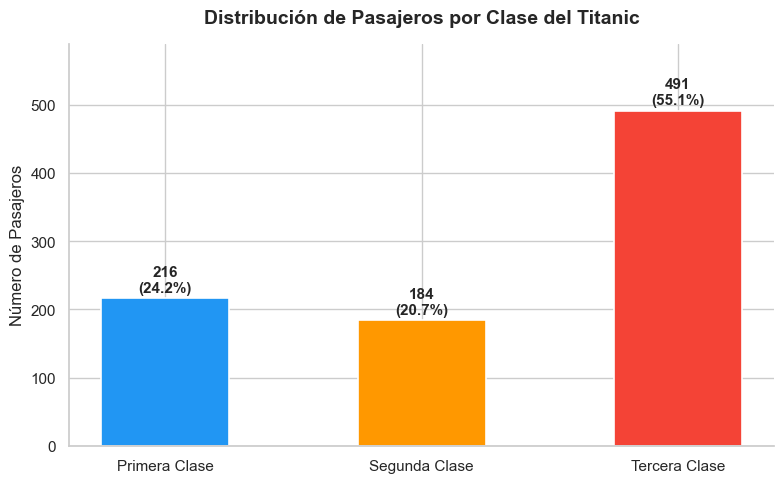

In [8]:
class_counts = df['Pclass'].value_counts().sort_index() # Cuenta pasajeros por clase y ordena por índice (1, 2, 3)
class_labels = ['Primera Clase', 'Segunda Clase', 'Tercera Clase'] # Define las etiquetas legibles para el eje X
colors = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_labels, class_counts.values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)

for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribución de Pasajeros por Clase del Titanic', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Número de Pasajeros', fontsize=12)
ax.set_ylim(0, max(class_counts.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusión:** El Titanic no era igualitario en número de plazas. La Tercera Clase era la dominante con 491 pasajeros (55.1%), mientras que la Primera Clase tenía 216 (24.2%) y la Segunda Clase 184 (20.7%). El barco transportaba mayoritariamente emigrantes y personas de bajo poder adquisitivo.


### Versión Plotly

In [9]:
import plotly.graph_objects as go

class_counts_p1 = df['Pclass'].value_counts().sort_index()
class_labels_p1 = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']
pct_p1 = (class_counts_p1.values / len(df) * 100).round(1)

fig = go.Figure(go.Bar(
    x=class_labels_p1,
    y=class_counts_p1.values,
    marker_color=['#2196F3', '#FF9800', '#F44336'],
    text=[f'<b>{v}</b><br>({p}%)' for v, p in zip(class_counts_p1.values, pct_p1)],
    textposition='outside',
    customdata=list(zip(class_counts_p1.values, pct_p1)),
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Pasajeros: <b>%{customdata[0]}</b><br>'
        'Del total: <b>%{customdata[1]}%</b><extra></extra>'
    )
))
fig.update_layout(
    title='Distribución de Pasajeros por Clase del Titanic',
    xaxis_title='Clase Social',
    yaxis_title='Número de Pasajeros',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey', range=[0, max(class_counts_p1.values) * 1.25]),
    height=480,
    hoverlabel=dict(bgcolor='white', font_size=13)
)
fig.show()


### Pregunta 2 — ¿Qué edades tenían los pasajeros?

**Tipo de gráfico elegido:** Histograma
- **Justificación:** La edad es una variable numérica continua. El histograma muestra la distribución completa. Es el gráfico estándar para explorar distribuciones de variables continuas.

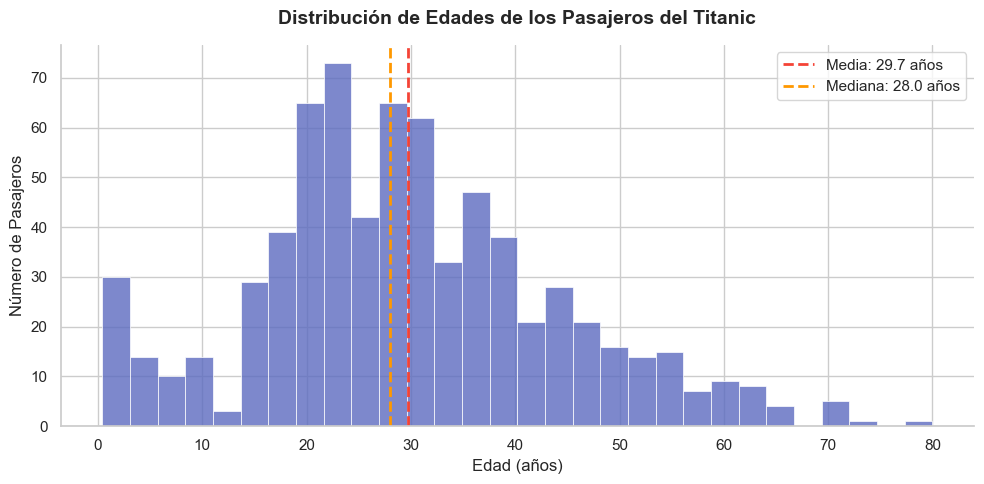

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['Age'].dropna(), bins=30, color='#5C6BC0', edgecolor='white',
             linewidth=0.5, ax=ax, alpha=0.8)

media = df['Age'].mean()
mediana = df['Age'].median()
ax.axvline(media, color='#F44336', linestyle='--', linewidth=2, label=f'Media: {media:.1f} años')
ax.axvline(mediana, color='#FF9800', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.1f} años')

ax.set_title('Distribución de Edades de los Pasajeros del Titanic', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Número de Pasajeros', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusión:** La distribución de edades está **sesgada hacia la derecha** con una moda alrededor de los 20-30 años. La mayoría de los pasajeros eran **adultos jóvenes** (20-35 años), lo que concuerda con el perfil de emigrantes buscando nuevas oportunidades. Existe un pico secundario en bebés/niños pequeños. Los valores extremos llegan hasta los 80 años.

---
### Versión Plotly (interactiva)

In [11]:
# ── Versión Plotly — Pregunta 2 ─────────────────────────────────────
import plotly.graph_objects as go

media_p2   = df['Age'].mean()
mediana_p2 = df['Age'].median()

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df['Age'].dropna(), nbinsx=30,
    marker_color='#5C6BC0', opacity=0.8, name='Pasajeros',
    hovertemplate='Rango de edad: %{x}<br>Pasajeros: %{y}<extra></extra>'
))
fig.add_vline(x=media_p2, line_dash='dash', line_color='#F44336', line_width=2,
              annotation_text=f'Media: {media_p2:.1f} años',
              annotation_position='top right',
              annotation_font=dict(color='#F44336', size=12))
fig.add_vline(x=mediana_p2, line_dash='dash', line_color='#FF9800', line_width=2,
              annotation_text=f'Mediana: {mediana_p2:.1f} años',
              annotation_position='top left',
              annotation_font=dict(color='#FF9800', size=12))
fig.update_layout(
    title='Distribución de Edades de los Pasajeros del Titanic',
    xaxis_title='Edad (años)',
    yaxis_title='Número de Pasajeros',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    height=480,
    hoverlabel=dict(bgcolor='white', font_size=13)
)
fig.show()


### Pregunta 3 — ¿Existía diferencia de edad entre clases sociales?

**Tipo de gráfico elegido:** Boxplot (diagrama de caja)  
**Justificación:** El boxplot permite comparar simultáneamente la mediana, la dispersión, los valores atípicos y la forma de la distribución de una variable numérica entre múltiples grupos categóricos. Es ideal para comparar distribuciones entre 3 clases.

C:\Users\majo1\AppData\Local\Temp\ipykernel_11512\759183518.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Clase', y='Age', palette=['#2196F3', '#FF9800', '#F44336'],


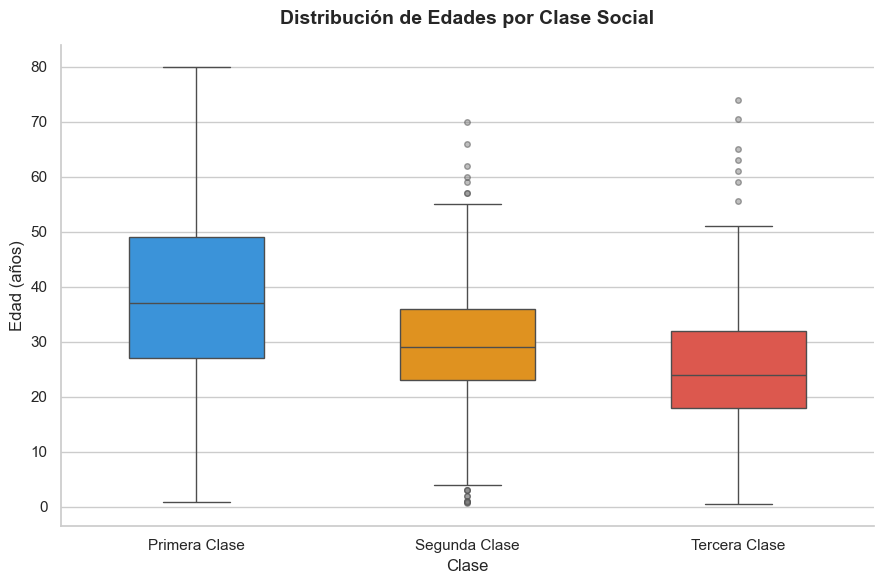

Mediana de edad por clase:
Pclass
Primera Clase    37.0
Segunda Clase    29.0
Tercera Clase    24.0
Name: Age, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

df_plot = df.copy()
df_plot['Clase'] = df_plot['Pclass'].map({1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'})

sns.boxplot(data=df_plot, x='Clase', y='Age', palette=['#2196F3', '#FF9800', '#F44336'],
            order=['Primera Clase', 'Segunda Clase', 'Tercera Clase'], width=0.5, ax=ax,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))

ax.set_title('Distribución de Edades por Clase Social', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Edad (años)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Mediana de edad por clase:')
print(df.groupby('Pclass')['Age'].median().rename({1:'Primera Clase', 2:'Segunda Clase', 3:'Tercera Clase'}))

**Conclusión:** Sí existían **diferencias de edad significativas entre clases**. Los pasajeros de Primera Clase eran los mayores (mediana 37 años), lo que refleja que eran personas económicamente establecidas. La Tercera Clase tenía la mediana más baja (25 años), confirmando que eran principalmente jóvenes emigrantes. La Segunda Clase se situaba en un punto intermedio (29 años). La dispersión es mayor en Primera Clase.


### Versión Plotly

In [13]:
clases_p3  = {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}
colores_p3 = {'Primera Clase': '#2196F3', 'Segunda Clase': '#FF9800', 'Tercera Clase': '#F44336'}

fig = go.Figure()
for pclass, nombre in clases_p3.items():
    datos = df[df['Pclass'] == pclass]['Age'].dropna()
    fig.add_trace(go.Box(
        y=datos, name=nombre,
        marker_color=colores_p3[nombre], boxpoints='outliers',
        hovertemplate=f'<b>{nombre}</b><br>Edad: %{{y:.1f}} años<extra></extra>'
    ))
fig.update_layout(
    title='Distribución de Edades por Clase Social',
    yaxis_title='Edad (años)',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    height=500,
    hoverlabel=dict(bgcolor='white', font_size=13)
)
fig.show()

print('Mediana de edad por clase:')
print(df.groupby('Pclass')['Age'].median().rename(
    {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}))


Mediana de edad por clase:
Pclass
Primera Clase    37.0
Segunda Clase    29.0
Tercera Clase    24.0
Name: Age, dtype: float64



## PARTE II — El Dinero a Bordo

### Pregunta 4 — ¿Cuánto se pagó por viajar en el Titanic?

**Tipo de gráfico elegido:** Histograma con escala logarítmica  
**Justificación:** La variable Fare tiene una distribución extremadamente sesgada con valores atípicos muy altos (hasta 512 libras). Un histograma normal comprimiría todos los datos en los valores bajos. La escala logarítmica en el eje X permite visualizar toda la distribución correctamente, revelando tanto los valores bajos frecuentes como los extremos.

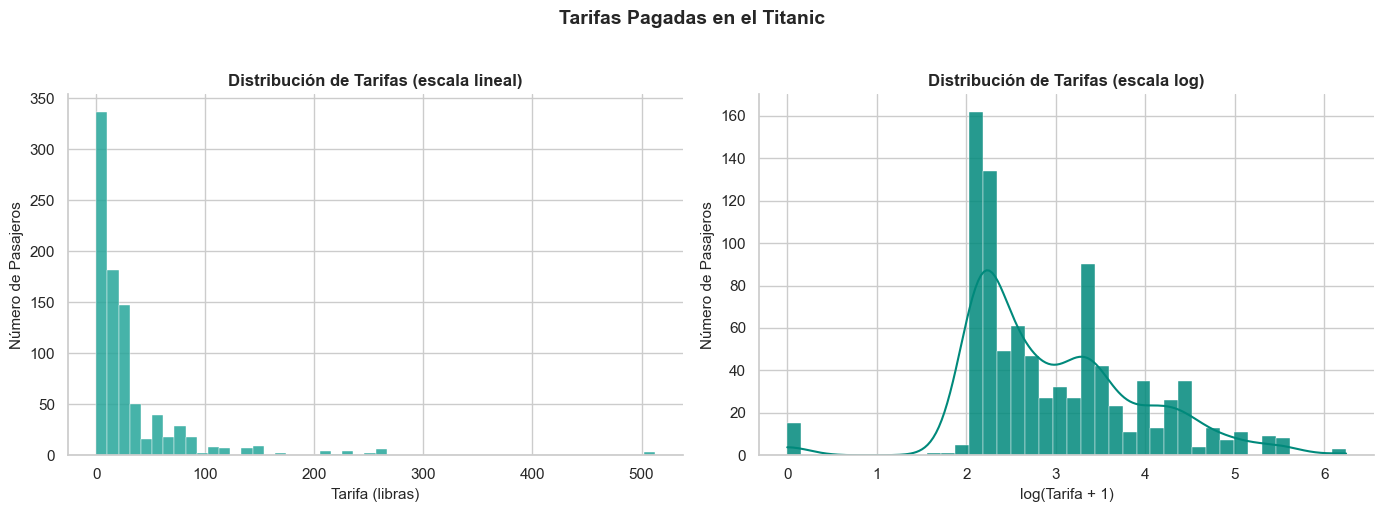

Tarifa mínima: £0.00
Tarifa mediana: £14.45
Tarifa máxima: £512.33
Tarifa media: £32.20


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
sns.histplot(df['Fare'], bins=50, color='#26A69A', edgecolor='white', linewidth=0.3, ax=axes[0], alpha=0.85)
axes[0].set_title('Distribución de Tarifas (escala lineal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tarifa (libras)', fontsize=11)
axes[0].set_ylabel('Número de Pasajeros', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Histograma con log
fare_log = np.log1p(df['Fare'])
sns.histplot(fare_log, bins=40, color='#00897B', edgecolor='white', linewidth=0.3, ax=axes[1], alpha=0.85, kde=True)
axes[1].set_title('Distribución de Tarifas (escala log)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Tarifa + 1)', fontsize=11)
axes[1].set_ylabel('Número de Pasajeros', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Tarifas Pagadas en el Titanic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Tarifa mínima: £{df["Fare"].min():.2f}')
print(f'Tarifa mediana: £{df["Fare"].median():.2f}')
print(f'Tarifa máxima: £{df["Fare"].max():.2f}')
print(f'Tarifa media: £{df["Fare"].mean():.2f}')

**Conclusión:** La mayoría de los pasajeros pagó tarifas bajas (mediana 14libras), mientras que una minoría pagó precios extremadamente altos (hasta 512libras). Esto confirma que el Titanic transportaba principalmente pasajeros de bajo poder adquisitivo, con una pequeña élite de pasajeros muy ricos que distorsiona la media (32libras).


### Versión Plotly

In [15]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

fare_log_p4 = np.log1p(df['Fare'])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Distribución de Tarifas (escala lineal)',
                    'Distribución de Tarifas (escala log)']
)
fig.add_trace(go.Histogram(
    x=df['Fare'], nbinsx=50,
    marker_color='#26A69A', opacity=0.85, name='Tarifa',
    hovertemplate='Tarifa: £%{x:.1f}<br>Pasajeros: %{y}<extra></extra>'
), row=1, col=1)
fig.add_trace(go.Histogram(
    x=fare_log_p4, nbinsx=40,
    marker_color='#00897B', opacity=0.85, name='log(Tarifa+1)',
    hovertemplate='log(Tarifa+1): %{x:.2f}<br>Pasajeros: %{y}<extra></extra>'
), row=1, col=2)
fig.update_layout(
    title='Tarifas Pagadas en el Titanic',
    showlegend=False, plot_bgcolor='white', height=460,
    hoverlabel=dict(bgcolor='white', font_size=12)
)
fig.update_xaxes(title_text='Tarifa (libras £)', row=1, col=1)
fig.update_xaxes(title_text='log(Tarifa + 1)', row=1, col=2)
fig.update_yaxes(title_text='Número de Pasajeros', gridcolor='lightgrey')
fig.show()

print(f'Tarifa mínima:  £{df["Fare"].min():.2f}')
print(f'Tarifa mediana: £{df["Fare"].median():.2f}')
print(f'Tarifa media:   £{df["Fare"].mean():.2f}')
print(f'Tarifa máxima:  £{df["Fare"].max():.2f}')


Tarifa mínima:  £0.00
Tarifa mediana: £14.45
Tarifa media:   £32.20
Tarifa máxima:  £512.33


### Pregunta 5 — ¿La clase social determinaba cuánto se pagaba?

**Tipo de gráfico elegido:** Violin plot + boxplot combinado  
**Justificación:** El violin plot muestra la forma completa de la distribución (incluyendo bimodalidades), mientras que el boxplot superpuesto añade los valores estadísticos precisos (mediana, cuartiles, outliers). La combinación es más informativa que cualquiera de los dos por separado para comparar dispersión entre clases.

C:\Users\majo1\AppData\Local\Temp\ipykernel_11512\1483230686.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Clase', y='Fare', palette=['#2196F3', '#FF9800', '#F44336'],


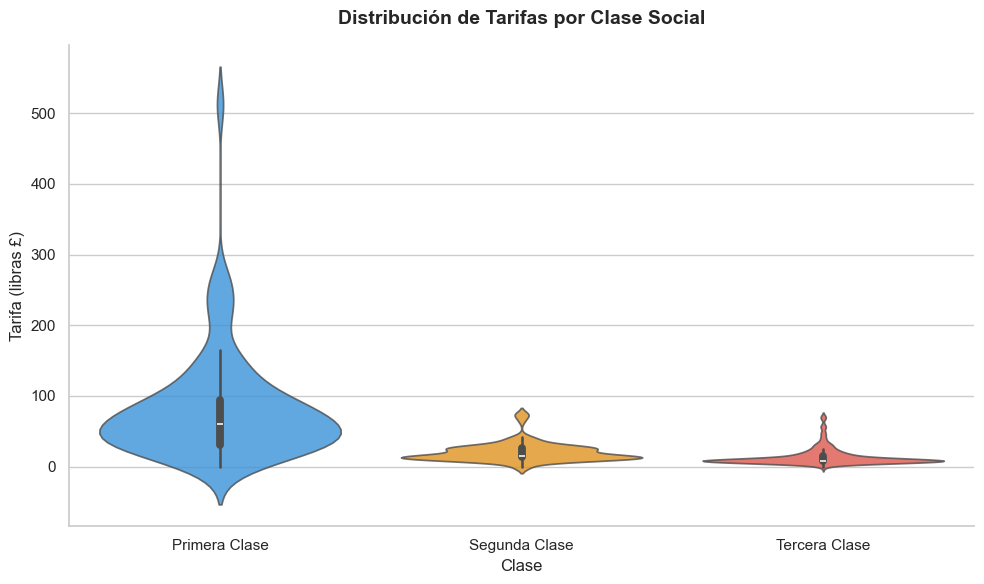

Estadísticas de tarifa por clase:
               count   mean    std  min    25%    50%   75%     max
Pclass                                                             
Primera Clase  216.0  84.15  78.38  0.0  30.92  60.29  93.5  512.33
Segunda Clase  184.0  20.66  13.42  0.0  13.00  14.25  26.0   73.50
Tercera Clase  491.0  13.68  11.78  0.0   7.75   8.05  15.5   69.55


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df.copy()
df_plot['Clase'] = df_plot['Pclass'].map({1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'})

sns.violinplot(data=df_plot, x='Clase', y='Fare', palette=['#2196F3', '#FF9800', '#F44336'],
               order=['Primera Clase', 'Segunda Clase', 'Tercera Clase'], inner='box', ax=ax, alpha=0.8)

ax.set_title('Distribución de Tarifas por Clase Social', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Tarifa (libras £)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Estadísticas de tarifa por clase:')
print(df.groupby('Pclass')['Fare'].describe().round(2).rename(index={1:'Primera Clase', 2:'Segunda Clase', 3:'Tercera Clase'}))

**Conclusión:** La clase social sí determinaba fuertemente la tarifa. La Primera Clase pagaba en promedio 84Libras con una variabilidad enorme (de 25libras a 512libras), lo que indica que incluso entre iguales había grandes diferencias. La Segunda Clase pagaba 21libras y la Tercera Clase 13libra. Lo más llamativo es la grandísima dispersión en Primera Clase: no todos los ricos pagaban lo mismo.


### Versión Plotly

In [17]:
import plotly.graph_objects as go

clases_p5  = {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}
colores_p5 = ['#2196F3', '#FF9800', '#F44336']

fig = go.Figure()
for (pclass, nombre), color in zip(clases_p5.items(), colores_p5):
    datos = df[df['Pclass'] == pclass]['Fare']
    fig.add_trace(go.Violin(
        y=datos, name=nombre,
        fillcolor=color, line_color=color, opacity=0.7,
        box_visible=True, meanline_visible=True,
        hovertemplate=f'<b>{nombre}</b><br>Tarifa: £%{{y:.2f}}<extra></extra>'
    ))
fig.update_layout(
    title='Distribución de Tarifas por Clase Social',
    yaxis_title='Tarifa (libras £)',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    height=550,
    hoverlabel=dict(bgcolor='white', font_size=13)
)
fig.show()


### Pregunta 6 — ¿La riqueza está relacionada con la edad?

**Tipo de gráfico elegido:** Scatter plot (diagrama de dispersión) con coloreado por clase  
**Justificación:** Para explorar la relación entre dos variables numéricas continuas (edad y tarifa), el scatter plot es el gráfico natural. Colorear por clase añade una tercera dimensión que enriquece el análisis y permite ver si los grupos se comportan de manera diferente.

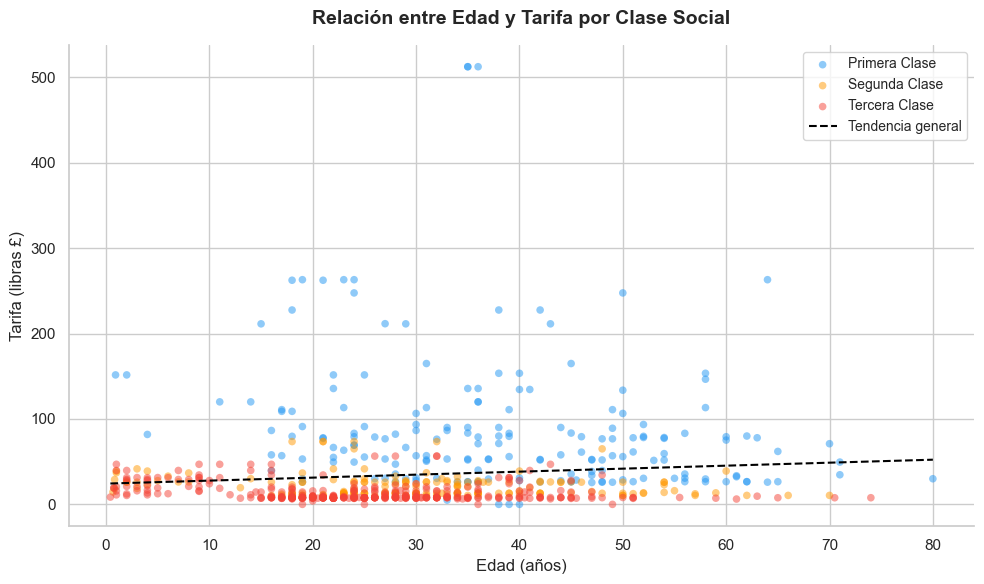

Correlación Pearson (Edad vs Tarifa): 0.096


In [18]:
df_clean = df.dropna(subset=['Age', 'Fare']).copy()
df_clean['Clase'] = df_clean['Pclass'].map({1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'})

fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'Primera Clase': '#2196F3', 'Segunda Clase': '#FF9800', 'Tercera Clase': '#F44336'}
for clase, grupo in df_clean.groupby('Clase'):
    ax.scatter(grupo['Age'], grupo['Fare'], c=colors_map[clase], label=clase,
               alpha=0.5, s=30, edgecolors='none')

# Línea de tendencia general
z = np.polyfit(df_clean['Age'], df_clean['Fare'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['Age'].min(), df_clean['Age'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, label='Tendencia general')

ax.set_title('Relación entre Edad y Tarifa por Clase Social', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Tarifa (libras £)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

corr = df_clean['Age'].corr(df_clean['Fare'])
print(f'Correlación Pearson (Edad vs Tarifa): {corr:.3f}')

**Conclusión:** La relación entre edad y tarifa es débil (correlación 0.09). No existe una tendencia clara que indique que los pasajeros mayores pagaran más. Los valores extremos de tarifa corresponden casi exclusivamente a la Primera Clase (azul), independientemente de la edad. La clase social, no la edad, es el factor determinante del precio pagado.


### Versión Plotly

In [19]:
import plotly.express as px

df_clean_p6 = df.dropna(subset=['Age', 'Fare']).copy()
df_clean_p6['Clase']      = df_clean_p6['Pclass'].map({1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'})
df_clean_p6['Sexo']       = df_clean_p6['Sex'].map({'male': 'Hombre', 'female': 'Mujer'})
df_clean_p6['Sobrevivió'] = df_clean_p6['Survived'].map({0: 'No', 1: 'Sí'})

fig = px.scatter(
    df_clean_p6, x='Age', y='Fare', color='Clase',
    color_discrete_map={
        'Primera Clase': '#2196F3',
        'Segunda Clase': '#FF9800',
        'Tercera Clase': '#F44336'
    },
    hover_name='Name',
    hover_data={'Age': ':.1f', 'Fare': ':.2f', 'Sexo': True,
                'Sobrevivió': True, 'Clase': False},
    opacity=0.55,
    trendline='ols',
    labels={'Age': 'Edad (años)', 'Fare': 'Tarifa (£)', 'Clase': 'Clase Social'},
    title='Relación entre Edad y Tarifa por Clase Social'
)
fig.update_layout(
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    xaxis=dict(gridcolor='lightgrey'),
    height=550,
    hoverlabel=dict(bgcolor='white', font_size=12)
)
fig.show()

corr_p6 = df_clean_p6['Age'].corr(df_clean_p6['Fare'])
print(f'Correlación Pearson (Edad vs Tarifa): {corr_p6:.3f}')


Correlación Pearson (Edad vs Tarifa): 0.096



## PARTE III — La Noche del Hundimiento

### Pregunta 7 — ¿Cuál fue la tasa de supervivencia global?

**Tipo de gráfico elegido:** Gráfico de pastel (pie chart)  
**Justificación:** Se quiere mostrar el **peso relativo** de dos grupos (sobrevivió / no sobrevivió) dentro del total. El pie chart es el gráfico más adecuado para mostrar proporciones de un todo cuando hay pocas categorías (2), haciendo inmediatamente visible qué grupo fue mayor.

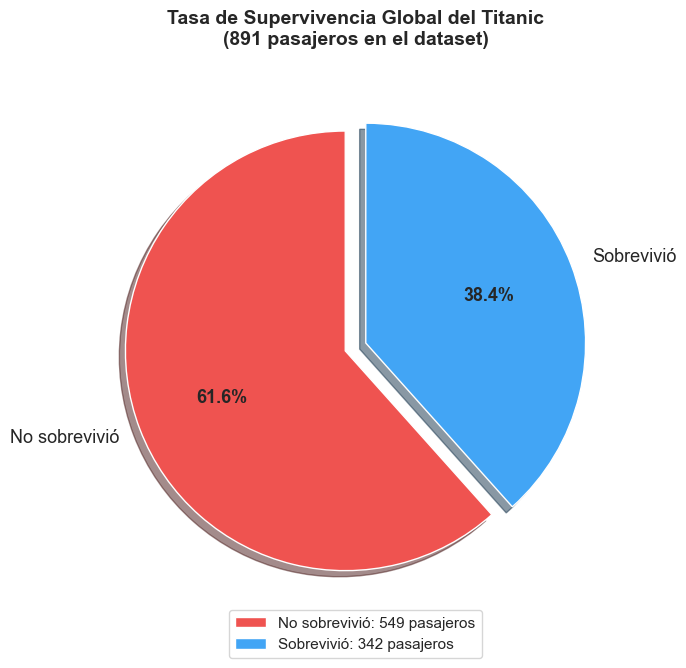

In [20]:
survival_counts = df['Survived'].value_counts()
labels = ['No sobrevivió', 'Sobrevivió']
colors = ['#EF5350', '#42A5F5']
explode = (0.05, 0.05)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    survival_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 13}
)
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

ax.set_title('Tasa de Supervivencia Global del Titanic\n(891 pasajeros en el dataset)',
             fontsize=14, fontweight='bold', pad=20)

legend_labels = [f'{labels[i]}: {survival_counts.values[i]} pasajeros' for i in range(2)]
ax.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=11)
plt.tight_layout()
plt.show()

**Conclusión:** Solo el **38.4% de los pasajeros sobrevivió** (342 personas), mientras que el **61.6% perdió la vida** (549 personas). Casi 2 de cada 3 pasajeros murieron. Esta proporción demuestra la magnitud de la tragedia y establece la base para analizar qué factores determinaron quién entraba en ese 38.4%.


### Versión Plotly

In [21]:
import plotly.graph_objects as go

surv_counts_p7 = df['Survived'].value_counts().sort_index()

fig = go.Figure(go.Pie(
    labels=['No sobrevivió', 'Sobrevivió'],
    values=surv_counts_p7.values,
    marker=dict(colors=['#EF5350', '#42A5F5'],
                line=dict(color='white', width=3)),
    pull=[0.05, 0.05],
    textinfo='label+percent',
    customdata=surv_counts_p7.values,
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Pasajeros: <b>%{customdata}</b><br>'
        'Porcentaje: <b>%{percent}</b><extra></extra>'
    ),
    textfont=dict(size=14)
))
fig.update_layout(
    title=dict(
        text='Tasa de Supervivencia Global del Titanic<br><sup>891 pasajeros en el dataset</sup>',
        font=dict(size=15)
    ),
    height=500,
    legend=dict(font=dict(size=12))
)
fig.show()


### Pregunta 8 — ¿Importó la clase social para sobrevivir?

**Tipo de gráfico elegido:** Gráfico de barras apiladas (stacked bar) + barras agrupadas  
**Justificación:** Se necesita ver tanto los **números absolutos** como las **proporciones** de supervivencia por clase. Las barras agrupadas muestran cantidades absolutas y las barras apiladas normalizadas al 100% muestran proporciones comparables entre clases de distinto tamaño.

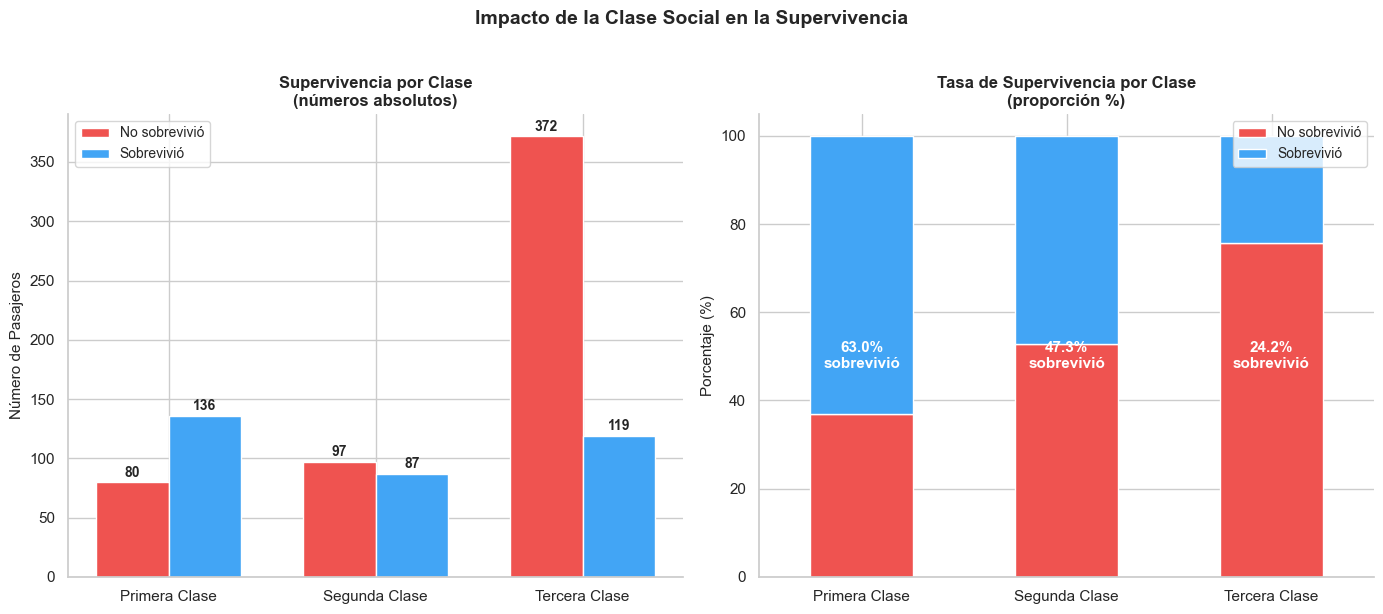

In [22]:
survival_class = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
survival_class.index = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']
survival_class.columns = ['No sobrevivió', 'Sobrevivió']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras agrupadas (números absolutos)
x = np.arange(3)
width = 0.35
bars1 = axes[0].bar(x - width/2, survival_class['No sobrevivió'], width, label='No sobrevivió',
                    color='#EF5350', edgecolor='white')
bars2 = axes[0].bar(x + width/2, survival_class['Sobrevivió'], width, label='Sobrevivió',
                    color='#42A5F5', edgecolor='white')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Supervivencia por Clase\n(números absolutos)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Primera Clase', 'Segunda Clase', 'Tercera Clase'])
axes[0].set_ylabel('Número de Pasajeros', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Barras apiladas normalizadas (proporciones)
survival_pct = survival_class.div(survival_class.sum(axis=1), axis=0) * 100
survival_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#EF5350', '#42A5F5'],
                  edgecolor='white', width=0.5)

for i, clase in enumerate(survival_pct.index):
    pct_surv = survival_pct.loc[clase, 'Sobrevivió']
    axes[1].text(i, 50, f'{pct_surv:.1f}%\nsobrevivió', ha='center', va='center',
                 fontsize=11, fontweight='bold', color='white')

axes[1].set_title('Tasa de Supervivencia por Clase\n(proporción %)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)', fontsize=11)
axes[1].set_xticklabels(['Primera Clase', 'Segunda Clase', 'Tercera Clase'], rotation=0)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Impacto de la Clase Social en la Supervivencia', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:** La clase social fue determinante para sobrevivir. La Primera Clase tuvo una tasa de supervivencia del 63%, la Segunda Clase del 47%, y la Tercera Clase solo del 24%. Un pasajero de Primra Clase tenía más del doble de probabilidad de sobrevivir que uno de Tercera Clase. El acceso restringido a las cubiertas y botes salvavidas para los pasajeros de clase baja quedó reflejado mortalmente en los datos.


### Versión Plotly

In [23]:
sc_p8 = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
sc_p8.index   = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']
sc_p8.columns = ['No sobrevivió', 'Sobrevivió']
sc_pct_p8 = sc_p8.div(sc_p8.sum(axis=1), axis=0) * 100

# Figura 1: números absolutos (barras agrupadas)
fig1 = go.Figure()
for col, color in zip(['No sobrevivió', 'Sobrevivió'], ['#EF5350', '#42A5F5']):
    fig1.add_trace(go.Bar(
        name=col, x=sc_p8.index, y=sc_p8[col],
        marker_color=color,
        text=sc_p8[col].values, textposition='outside',
        hovertemplate='<b>%{x}</b><br>' + col + ': <b>%{y}</b> pasajeros<extra></extra>'
    ))
fig1.update_layout(
    title='Supervivencia por Clase — Números Absolutos',
    barmode='group', yaxis_title='Número de Pasajeros',
    plot_bgcolor='white', yaxis=dict(gridcolor='lightgrey'),
    height=460, hoverlabel=dict(bgcolor='white', font_size=12)
)
fig1.show()

# Figura 2: proporciones 100% (barras apiladas)
fig2 = go.Figure()
for col, color in zip(['No sobrevivió', 'Sobrevivió'], ['#EF5350', '#42A5F5']):
    fig2.add_trace(go.Bar(
        name=col, x=sc_pct_p8.index, y=sc_pct_p8[col].round(1),
        marker_color=color,
        text=sc_pct_p8[col].round(1).astype(str) + '%',
        textposition='inside',
        hovertemplate='<b>%{x}</b><br>' + col + ': <b>%{y:.1f}%</b><extra></extra>'
    ))
fig2.update_layout(
    title='Supervivencia por Clase — Proporciones (%)',
    barmode='stack', yaxis_title='Porcentaje (%)',
    plot_bgcolor='white', yaxis=dict(gridcolor='lightgrey'),
    height=460, hoverlabel=dict(bgcolor='white', font_size=12)
)
fig2.show()


### Pregunta 9 — ¿Se cumplió el protocolo 'mujeres y niños primero'?

**Tipo de gráfico elegido:** Barras agrupadas por clase y sexo + heatmap de tasas  
**Justificación:** Necesitamos visualizar tres variables simultáneamente (supervivencia, sexo, clase). Las barras agrupadas muestran las diferencias de manera intuitiva, y el heatmap añade una lectura rápida de tasas porcentuales que facilita las comparaciones cruzadas.

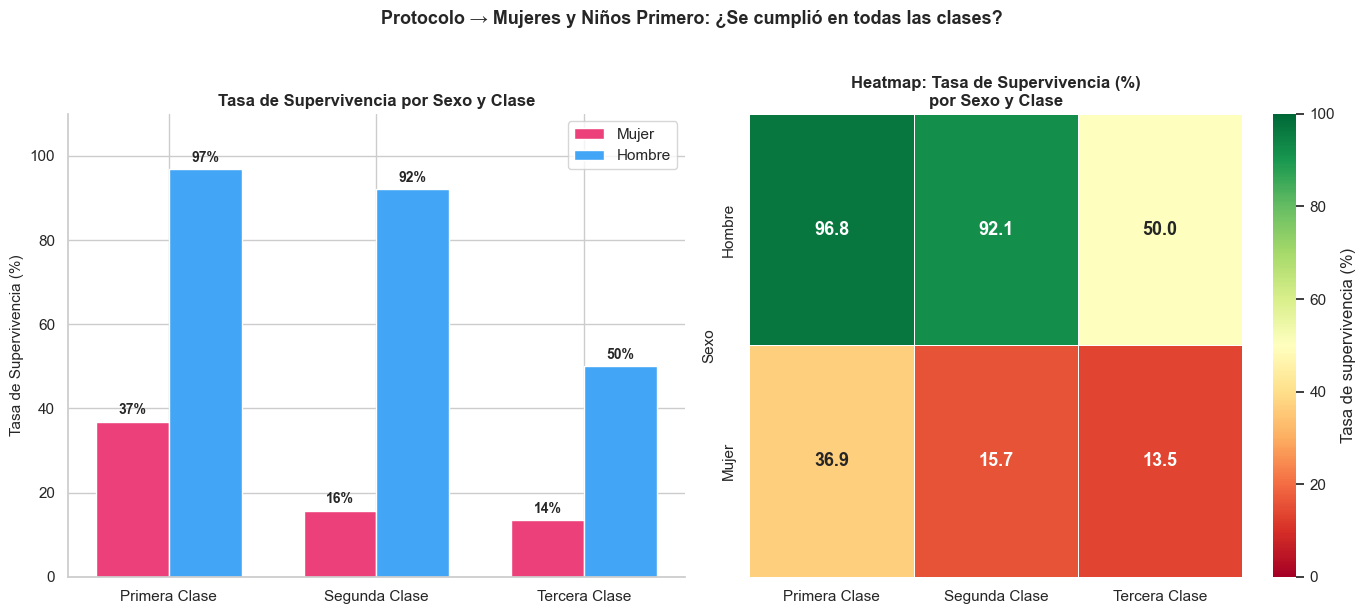

In [24]:
survival_sex_class = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
survival_sex_class.index = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']
survival_sex_class.columns = ['Hombre', 'Mujer']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras agrupadas
x = np.arange(3)
width = 0.35
axes[0].bar(x - width/2, survival_sex_class['Mujer'], width, label='Mujer',
            color='#EC407A', edgecolor='white')
axes[0].bar(x + width/2, survival_sex_class['Hombre'], width, label='Hombre',
            color='#42A5F5', edgecolor='white')

for i, (m, h) in enumerate(zip(survival_sex_class['Mujer'], survival_sex_class['Hombre'])):
    axes[0].text(i - width/2, m + 1, f'{m:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, h + 1, f'{h:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Tasa de Supervivencia por Sexo y Clase', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Primera Clase', 'Segunda Clase', 'Tercera Clase'])
axes[0].set_ylabel('Tasa de Supervivencia (%)', fontsize=11)
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Heatmap
sns.heatmap(survival_sex_class.T, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=100,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Tasa de supervivencia (%)'})
axes[1].set_title('Heatmap: Tasa de Supervivencia (%)\npor Sexo y Clase', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sexo', fontsize=11)

fig.suptitle("Protocolo → Mujeres y Niños Primero: ¿Se cumplió en todas las clases?",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:** El protocolo se cumplió, pero de forma desigual según la clase. Las mujeres de Primera y Segunda Clase tuvieron tasas de supervivencia altísimas (97% y 92% respectivamente). Sin embargo, las mujeres de Tercera Clase solo sobrevivieron al 50%, similar a los hombres de Primera Clase (37%). El protocolo favoreció fuertemente a las clases altas. Los hombres de Tercera Clase tuvieron la tasa más baja (17%), evidenciando una doble discriminación: de género Y de clase.


### Versión Plotly

In [25]:
ssc_p9 = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
ssc_p9.index   = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']
ssc_p9.columns = ['Hombre', 'Mujer']

# Barras agrupadas
fig1 = go.Figure()
for sexo, color in zip(['Mujer', 'Hombre'], ['#EC407A', '#42A5F5']):
    fig1.add_trace(go.Bar(
        name=sexo, x=ssc_p9.index, y=ssc_p9[sexo].round(1),
        marker_color=color,
        text=ssc_p9[sexo].round(0).astype(int).astype(str) + '%',
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>' + sexo + ': <b>%{y:.1f}%</b> sobrevivió<extra></extra>'
    ))
fig1.update_layout(
    title='Tasa de Supervivencia por Sexo y Clase',
    barmode='group', yaxis_title='Tasa de Supervivencia (%)',
    plot_bgcolor='white', yaxis=dict(gridcolor='lightgrey', range=[0, 115]),
    height=480, hoverlabel=dict(bgcolor='white', font_size=12)
)
fig1.show()

# Heatmap interactivo
fig2 = go.Figure(go.Heatmap(
    z=ssc_p9.T.values,
    x=ssc_p9.index.tolist(),
    y=['Hombre', 'Mujer'],
    colorscale='RdYlGn', zmin=0, zmax=100,
    text=ssc_p9.T.round(1).values,
    texttemplate='%{text:.1f}%',
    textfont=dict(size=14, color='black'),
    hovertemplate=(
        '<b>%{y}</b> · <b>%{x}</b><br>'
        'Tasa de supervivencia: <b>%{z:.1f}%</b><extra></extra>'
    ),
    colorbar=dict(title='%')
))
fig2.update_layout(
    title='Heatmap — Tasa de Supervivencia (%) por Sexo y Clase',
    xaxis_title='Clase', yaxis_title='Sexo',
    height=380
)
fig2.show()


### Pregunta 10 — ¿Tuvo la edad algún papel en la supervivencia?

**Tipo de gráfico elegido:** Histograma superpuesto con KDE  
**Justificación:** Para comparar la distribución de edades entre dos grupos (sobrevivió/no sobrevivió), los histogramas superpuestos con transparencia permiten identificar visualmente en qué rangos de edad una distribución supera a la otra. La curva KDE suaviza la comparación.

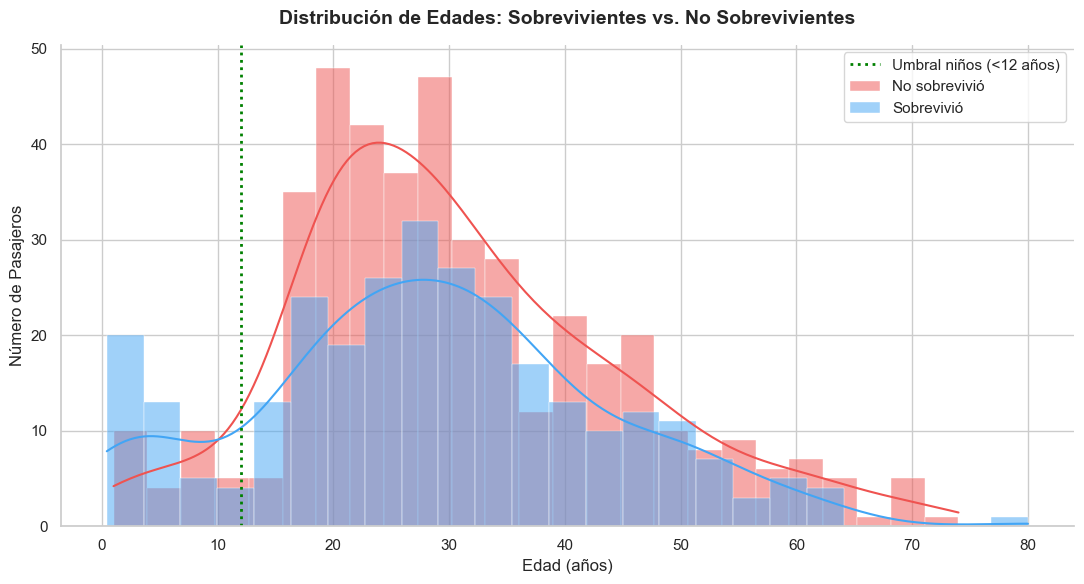

Tasa de supervivencia por grupo de edad:
grupo_edad
Niños\n(0-12)               58.0
Adolescentes\n(13-18)       42.9
Adultos jóvenes\n(19-30)    35.6
Adultos\n(31-50)            42.3
Mayores\n(51+)              34.4
Name: Survived, dtype: float64


In [26]:
survived = df[df['Survived'] == 1]['Age'].dropna()
no_survived = df[df['Survived'] == 0]['Age'].dropna()

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(no_survived, bins=25, kde=True, color='#EF5350', alpha=0.5,
             label='No sobrevivió', ax=ax, edgecolor='white', linewidth=0.3)
sns.histplot(survived, bins=25, kde=True, color='#42A5F5', alpha=0.5,
             label='Sobrevivió', ax=ax, edgecolor='white', linewidth=0.3)

ax.axvline(12, color='green', linestyle=':', linewidth=2, label='Umbral niños (<12 años)')

ax.set_title('Distribución de Edades: Sobrevivientes vs. No Sobrevivientes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Número de Pasajeros', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Tasa de supervivencia por grupo de edad
df_age = df.dropna(subset=['Age']).copy()
df_age['grupo_edad'] = pd.cut(df_age['Age'], bins=[0,12,18,30,50,80],
                               labels=['Niños\n(0-12)', 'Adolescentes\n(13-18)',
                                       'Adultos jóvenes\n(19-30)', 'Adultos\n(31-50)', 'Mayores\n(51+)'])
tasa_edad = df_age.groupby('grupo_edad', observed=True)['Survived'].mean() * 100
print('Tasa de supervivencia por grupo de edad:')
print(tasa_edad.round(1))

**Conclusión:** La edad sí tuvo un papel, especialmente en los extremos. Los niños menores de 12 años tuvieron la mayor tasa de supervivencia (57%), coherente con el protocolo. Sin embargo, las distribuciones se solapan considerablemente en adultos. Los pasajeros de mediana edad (30-50 años) también muestran tasas relativas más altas. Los jóvenes de 20-30 años (mayoría de Tercera Clase) presentan mayor mortalidad, posiblemente por ser el grupo más numeroso y tener menor acceso a los botes.


### Versión Plotly

In [27]:
surv_p10    = df[df['Survived'] == 1]['Age'].dropna()
no_surv_p10 = df[df['Survived'] == 0]['Age'].dropna()

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=no_surv_p10, nbinsx=25,
    marker_color='#EF5350', opacity=0.6, name='No sobrevivió',
    hovertemplate='Edad: %{x:.0f} años<br>Pasajeros: %{y}<extra></extra>'
))
fig.add_trace(go.Histogram(
    x=surv_p10, nbinsx=25,
    marker_color='#42A5F5', opacity=0.6, name='Sobrevivió',
    hovertemplate='Edad: %{x:.0f} años<br>Pasajeros: %{y}<extra></extra>'
))
fig.add_vline(x=12, line_dash='dot', line_color='green', line_width=2,
              annotation_text='Umbral niños (<12 años)',
              annotation_position='top right',
              annotation_font=dict(color='green', size=11))
fig.update_layout(
    title='Distribución de Edades: Sobrevivientes vs. No Sobrevivientes',
    xaxis_title='Edad (años)', yaxis_title='Número de Pasajeros',
    barmode='overlay',
    plot_bgcolor='white', yaxis=dict(gridcolor='lightgrey'),
    height=500, hoverlabel=dict(bgcolor='white', font_size=12),
    legend=dict(x=0.75, y=0.95)
)
fig.show()

df_age_p10 = df.dropna(subset=['Age']).copy()
df_age_p10['grupo_edad'] = pd.cut(df_age_p10['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Niños (0-12)', 'Adolescentes (13-18)',
            'Adultos jóvenes (19-30)', 'Adultos (31-50)', 'Mayores (51+)'])
tasa_p10 = df_age_p10.groupby('grupo_edad', observed=True)['Survived'].mean() * 100
print('Tasa de supervivencia por grupo de edad:')
print(tasa_p10.round(1))


Tasa de supervivencia por grupo de edad:
grupo_edad
Niños (0-12)               58.0
Adolescentes (13-18)       42.9
Adultos jóvenes (19-30)    35.6
Adultos (31-50)            42.3
Mayores (51+)              34.4
Name: Survived, dtype: float64


---
## PARTE IV — Patrones Cruzados y Correlaciones

### Pregunta 11 — ¿Qué variables numéricas están más relacionadas entre sí?

**Tipo de gráfico elegido:** Heatmap de correlación  
**Justificación:** El heatmap de correlación es el estándar en ciencia de datos para explorar todas las correlaciones entre variables numéricas de una sola vez. La escala de color permite identificar instantáneamente relaciones fuertes (colores intensos) y débiles (colores pálidos), tanto positivas como negativas.

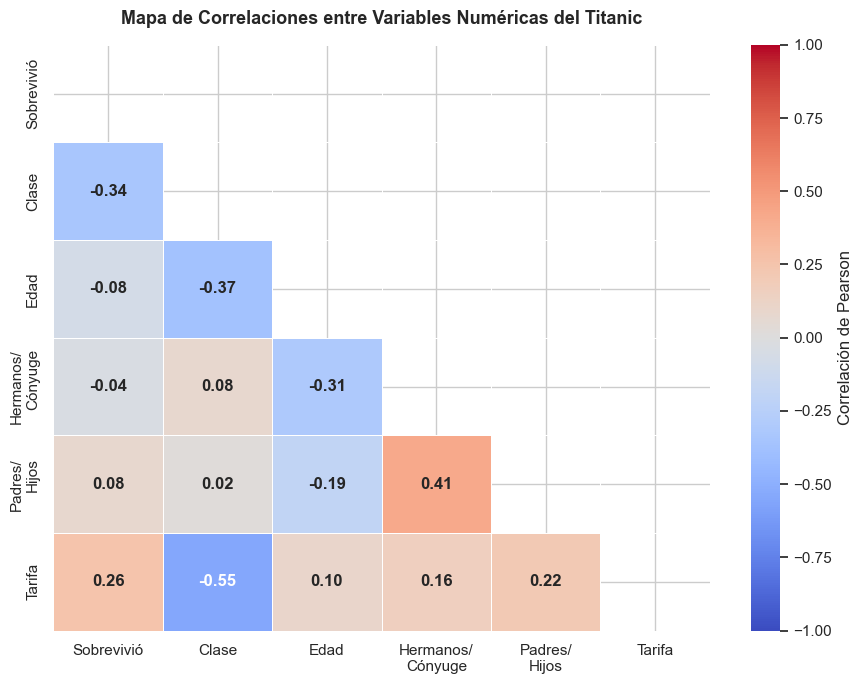

Par con correlación más fuerte (excluyendo diagonal):


ValueError: underlying array is read-only

In [28]:
vars_numericas = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[vars_numericas].corr()

labels_corr = {'Survived': 'Sobrevivió', 'Pclass': 'Clase', 'Age': 'Edad',
               'SibSp': 'Hermanos/\nCónyuge', 'Parch': 'Padres/\nHijos', 'Fare': 'Tarifa'}
corr_matrix_renamed = corr_matrix.rename(index=labels_corr, columns=labels_corr)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix_renamed, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlación de Pearson'})

ax.set_title('Mapa de Correlaciones entre Variables Numéricas del Titanic',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Par con correlación más fuerte (excluyendo diagonal):')
corr_upper = corr_matrix.where(mask == False)
np.fill_diagonal(corr_upper.values, np.nan)
idx = corr_upper.abs().stack().idxmax()
print(f'{idx[0]} — {idx[1]}: {corr_matrix.loc[idx[0], idx[1]]:.3f}')

**Conclusión:** El par con correlación más fuerte es Pclass y Fare (-0.55): cuanto más alta la clase (número menor), más cara la tarifa, lo cual es esperable. Lo más sorprendente es la correlación entre SibSp y Parch (0.41): viajar con hermanos/cónyuge y viajar con padres/hijos están relacionados, lo que indica que las familias numerosas tendían a viajar juntas en todos sus vínculos. La correlación entre Fare y Survived (0.26) confirma que pagar más aumentaba las probabilidades de sobrevivir.


### Versión Plotly

In [ ]:
vars_p11 = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_p11 = df[vars_p11].corr().round(2)
labels_p11 = {
    'Survived': 'Sobrevivió', 'Pclass': 'Clase', 'Age': 'Edad',
    'SibSp': 'Hermanos/Cónyuge', 'Parch': 'Padres/Hijos', 'Fare': 'Tarifa'
}
corr_p11 = corr_p11.rename(index=labels_p11, columns=labels_p11)

mask_p11 = np.triu(np.ones(corr_p11.shape, dtype=bool))
corr_masked = corr_p11.copy().astype(float)
corr_masked[mask_p11] = float('nan')

fig = go.Figure(go.Heatmap(
    z=corr_masked.values,
    x=corr_p11.columns.tolist(),
    y=corr_p11.index.tolist(),
    colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
    text=corr_masked.round(2).values,
    texttemplate='%{text}',
    textfont=dict(size=12, color='black'),
    hovertemplate=(
        '<b>%{y}</b> × <b>%{x}</b><br>'
        'Correlación de Pearson: <b>%{z:.2f}</b><extra></extra>'
    ),
    colorbar=dict(title='Correlación')
))
fig.update_layout(
    title='Mapa de Correlaciones entre Variables Numéricas del Titanic',
    height=560,
    xaxis=dict(side='bottom')
)
fig.show()


### Pregunta 12 — ¿Dónde embarcaron los pasajeros que sobrevivieron?

**Tipo de gráfico elegido:** Gráfico de barras agrupadas con desglose por clase  
**Justificación:** Se necesita visualizar tres variables categóricas simultáneamente (puerto, clase, supervivencia). Las barras agrupadas permiten comparar proporciones de supervivencia por puerto, y el desglose por clase revela por qué existen esas diferencias (composición del pasaje por puerto).

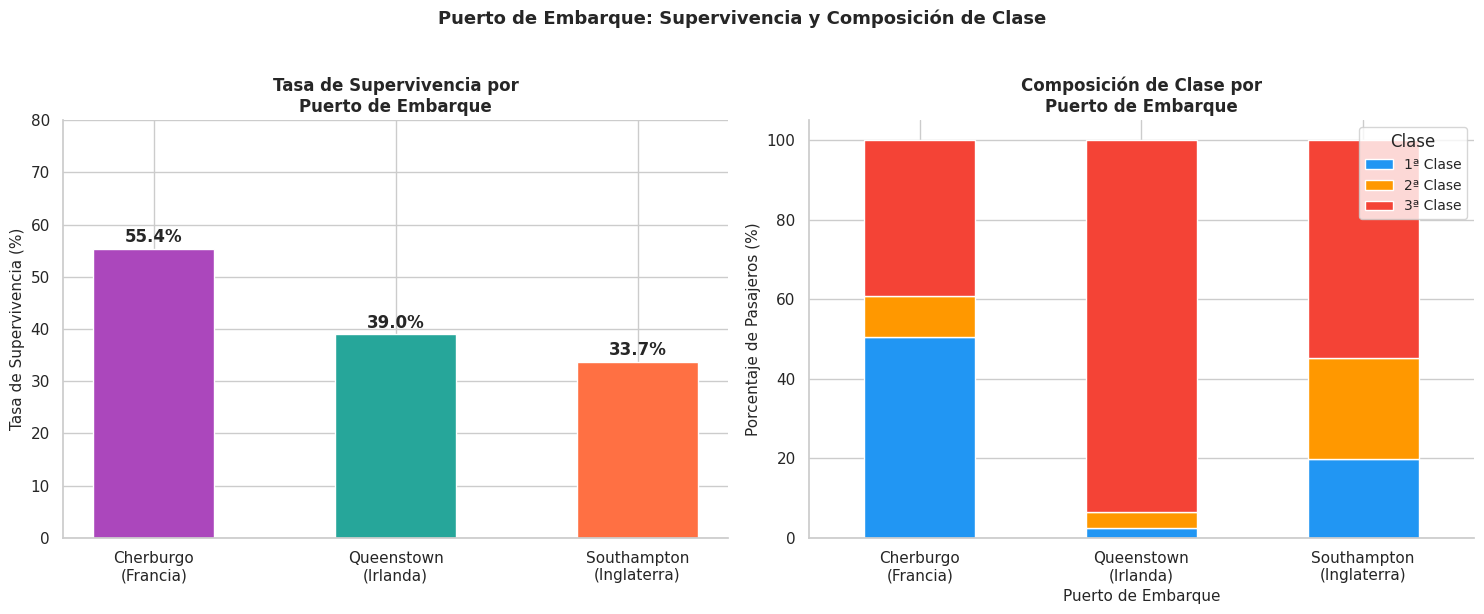

In [ ]:
df_emb = df.dropna(subset=['Embarked']).copy()
df_emb['Puerto'] = df_emb['Embarked'].map({'S': 'Southampton\n(Inglaterra)',
                                            'C': 'Cherburgo\n(Francia)',
                                            'Q': 'Queenstown\n(Irlanda)'})
df_emb['Clase'] = df_emb['Pclass'].map({1: '1ª Clase', 2: '2ª Clase', 3: '3ª Clase'})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tasa de supervivencia por puerto
surv_emb = df_emb.groupby('Puerto')['Survived'].mean() * 100
colors_emb = ['#AB47BC', '#26A69A', '#FF7043']
bars = axes[0].bar(surv_emb.index, surv_emb.values, color=colors_emb, edgecolor='white', width=0.5)
for bar, val in zip(bars, surv_emb.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Tasa de Supervivencia por\nPuerto de Embarque', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tasa de Supervivencia (%)', fontsize=11)
axes[0].set_ylim(0, 80)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Composición de clase por puerto (revela el por qué)
class_emb = df_emb.groupby(['Puerto', 'Clase']).size().unstack(fill_value=0)
class_emb_pct = class_emb.div(class_emb.sum(axis=1), axis=0) * 100
class_emb_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#2196F3', '#FF9800', '#F44336'], edgecolor='white', width=0.5)
axes[1].set_title('Composición de Clase por\nPuerto de Embarque', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje de Pasajeros (%)', fontsize=11)
axes[1].set_xlabel('Puerto de Embarque', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Clase', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Puerto de Embarque: Supervivencia y Composición de Clase',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:** Cherburgo (Francia) tuvo la mayor tasa de supervivencia (55%), seguido de Queenstown (39%) y Southampton (34%). La razón no es el puerto en sí, sino la composición del pasaje: Cherburgo embarcó proporcionalmente más pasajeros de Primera Clase (ricos que regresaban de Europa), mientras que Southampton y Queenstown embarcaron más pasajeros de Tercera Clase. Es un ejemplo claro de variable confusora: el puerto no causa la supervivencia, sino que actúa como proxy de la clase social.


### Versión Plotly

In [ ]:
df_emb_p12 = df.dropna(subset=['Embarked']).copy()
df_emb_p12['Puerto'] = df_emb_p12['Embarked'].map({
    'S': 'Southampton (Inglaterra)',
    'C': 'Cherburgo (Francia)',
    'Q': 'Queenstown (Irlanda)'
})
df_emb_p12['Clase'] = df_emb_p12['Pclass'].map({1: '1ª Clase', 2: '2ª Clase', 3: '3ª Clase'})

surv_emb_p12   = df_emb_p12.groupby('Puerto')['Survived'].mean() * 100
counts_emb_p12 = df_emb_p12.groupby('Puerto').size()

fig1 = go.Figure(go.Bar(
    x=surv_emb_p12.index,
    y=surv_emb_p12.values.round(1),
    marker_color=['#26A69A', '#AB47BC', '#FF7043'],
    text=[f'{v:.1f}%' for v in surv_emb_p12.values],
    textposition='outside',
    customdata=counts_emb_p12.reindex(surv_emb_p12.index).values,
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Tasa de supervivencia: <b>%{y:.1f}%</b><br>'
        'Total pasajeros embarcados: <b>%{customdata}</b><extra></extra>'
    )
))
fig1.update_layout(
    title='Tasa de Supervivencia por Puerto de Embarque',
    yaxis_title='Tasa de Supervivencia (%)',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey', range=[0, 80]),
    height=460,
    hoverlabel=dict(bgcolor='white', font_size=12)
)
fig1.show()

class_emb_p12     = df_emb_p12.groupby(['Puerto', 'Clase']).size().unstack(fill_value=0)
class_emb_pct_p12 = class_emb_p12.div(class_emb_p12.sum(axis=1), axis=0) * 100

fig2 = go.Figure()
for clase, color in zip(['1ª Clase', '2ª Clase', '3ª Clase'],
                         ['#2196F3', '#FF9800', '#F44336']):
    if clase in class_emb_pct_p12.columns:
        fig2.add_trace(go.Bar(
            name=clase,
            x=class_emb_pct_p12.index,
            y=class_emb_pct_p12[clase].round(1),
            marker_color=color,
            hovertemplate='<b>%{x}</b><br>' + clase + ': <b>%{y:.1f}%</b><extra></extra>'
        ))
fig2.update_layout(
    title='Composición de Clase por Puerto de Embarque',
    barmode='stack', yaxis_title='Porcentaje de Pasajeros (%)',
    plot_bgcolor='white', yaxis=dict(gridcolor='lightgrey'),
    height=460,
    hoverlabel=dict(bgcolor='white', font_size=12)
)
fig2.show()


### Pregunta 13 — ¿Viajar en familia protegía o perjudicaba?

**Tipo de gráfico elegido:** Línea de tasa de supervivencia por tamaño familiar  
**Justificación:** El tamaño familiar (SibSp + Parch) es una variable numérica ordinal. Un gráfico de líneas que muestra la tasa de supervivencia para cada valor del tamaño familiar revela si la relación es lineal, tiene un óptimo, o es no monotónica — algo que un simple boxplot no mostraría.

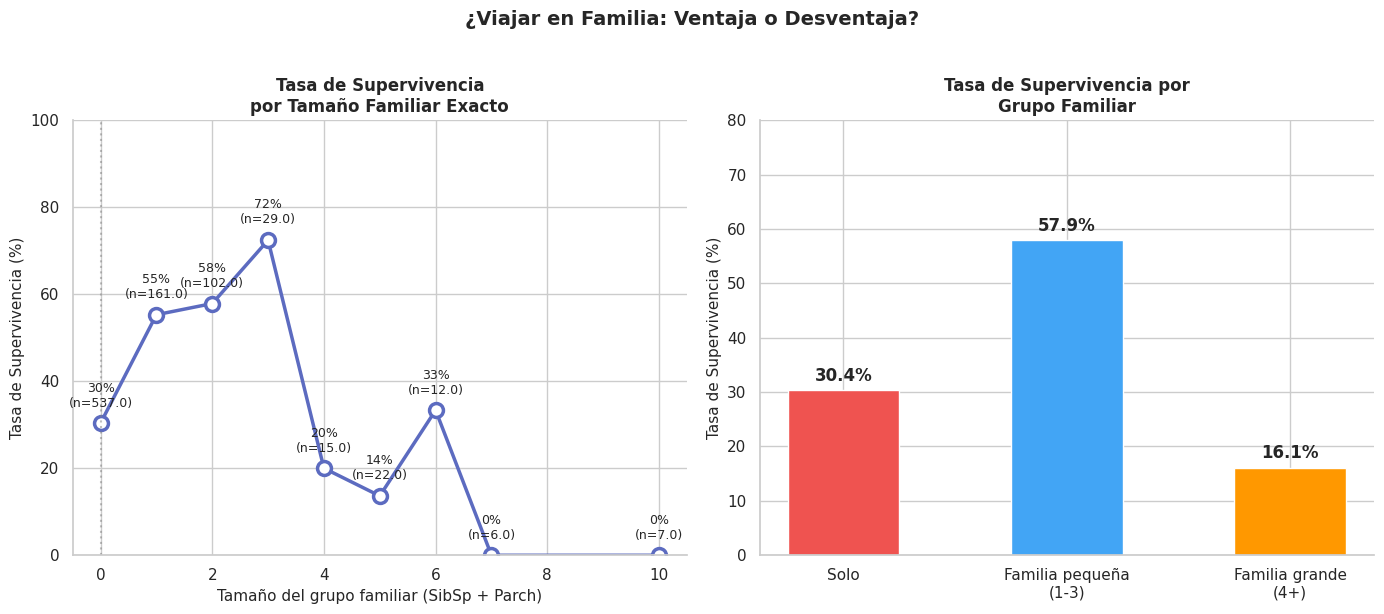

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df['FamilyGroup'] = df['FamilySize'].apply(
    lambda x: 'Solo' if x == 0 else ('Familia pequeña\n(1-3)' if x <= 3 else 'Familia grande\n(4+)')
)

surv_family = df.groupby('FamilySize')['Survived'].agg(['mean', 'count']).reset_index()
surv_family.columns = ['FamilySize', 'SurvRate', 'Count']
surv_family['SurvRate'] = surv_family['SurvRate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Línea de tasa por tamaño exacto
axes[0].plot(surv_family['FamilySize'], surv_family['SurvRate'],
             marker='o', color='#5C6BC0', linewidth=2.5, markersize=10, markerfacecolor='white',
             markeredgewidth=2.5)
for _, row in surv_family.iterrows():
    axes[0].annotate(f"{row['SurvRate']:.0f}%\n(n={row['Count']})",
                     (row['FamilySize'], row['SurvRate']),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9)
axes[0].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title('Tasa de Supervivencia\npor Tamaño Familiar Exacto', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tamaño del grupo familiar (SibSp + Parch)', fontsize=11)
axes[0].set_ylabel('Tasa de Supervivencia (%)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Barras por grupo familiar
surv_group = df.groupby('FamilyGroup')['Survived'].mean() * 100
order_groups = ['Solo', 'Familia pequeña\n(1-3)', 'Familia grande\n(4+)']
surv_group = surv_group.reindex(order_groups)
bars = axes[1].bar(surv_group.index, surv_group.values,
                   color=['#EF5350', '#42A5F5', '#FF9800'], edgecolor='white', width=0.5)
for bar, val in zip(bars, surv_group.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Tasa de Supervivencia por\nGrupo Familiar', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tasa de Supervivencia (%)', fontsize=11)
axes[1].set_ylim(0, 80)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('¿Viajar en Familia: Ventaja o Desventaja?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:** La relación entre tamaño familiar y supervivencia es no lineal y tiene un óptimo. Viajar solo tiene una tasa de 30%, las familias pequeñas (1-3 miembros) aumentan la supervivencia hasta 55%, pero las familias grandes (4+ miembros) caen drásticamente a 16%. Esto respalda ambas hipótesis: grupos pequeños se ayudaron mutuamente (ventaja), pero las familias muy numerosas se rezagaron por no querer separarse (desventaja). La familia pequeña era el tamaño óptimo para sobrevivir.

### Versión Plotly

In [ ]:
surv_fam_p13 = df.groupby('FamilySize')['Survived'].agg(['mean', 'count']).reset_index()
surv_fam_p13.columns = ['FamilySize', 'SurvRate', 'Count']
surv_fam_p13['SurvRate'] = (surv_fam_p13['SurvRate'] * 100).round(1)

groups_p13 = {
    'Solo (0)':               df[df['FamilySize'] == 0]['Survived'].mean() * 100,
    'Familia pequeña (1-3)':  df[df['FamilySize'].between(1, 3)]['Survived'].mean() * 100,
    'Familia grande (4+)':    df[df['FamilySize'] >= 4]['Survived'].mean() * 100,
}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Tasa de Supervivencia por Tamaño Familiar Exacto',
                    'Tasa de Supervivencia por Grupo Familiar']
)

fig.add_trace(go.Scatter(
    x=surv_fam_p13['FamilySize'], y=surv_fam_p13['SurvRate'],
    mode='lines+markers',
    marker=dict(size=12, color='#7E57C2', line=dict(color='white', width=2)),
    line=dict(color='#7E57C2', width=2.5),
    fill='tozeroy', fillcolor='rgba(126,87,194,0.12)',
    customdata=surv_fam_p13['Count'],
    hovertemplate=(
        '<b>%{x} familiar(es)</b><br>'
        'Supervivencia: <b>%{y:.1f}%</b><br>'
        'Pasajeros en este grupo: <b>%{customdata}</b><extra></extra>'
    )
), row=1, col=1)

fig.add_trace(go.Bar(
    x=list(groups_p13.keys()),
    y=[round(v, 1) for v in groups_p13.values()],
    marker_color=['#EF5350', '#42A5F5', '#FF9800'],
    text=[f'{v:.1f}%' for v in groups_p13.values()],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Supervivencia: <b>%{y:.1f}%</b><extra></extra>'
), row=1, col=2)

fig.update_layout(
    title='¿Viajar en Familia: Ventaja o Desventaja?',
    plot_bgcolor='white', showlegend=False, height=500,
    hoverlabel=dict(bgcolor='white', font_size=12)
)
fig.update_xaxes(title_text='Nº de familiares a bordo (SibSp + Parch)', row=1, col=1)
fig.update_xaxes(title_text='Grupo Familiar', row=1, col=2)
fig.update_yaxes(title_text='Tasa de Supervivencia (%)',
                 gridcolor='lightgrey', range=[0, 100], row=1, col=1)
fig.update_yaxes(title_text='Tasa de Supervivencia (%)',
                 gridcolor='lightgrey', range=[0, 80],  row=1, col=2)
fig.show()



## PARTE V — Síntesis: El Dashboard del Investigador

### Pregunta 14 — ¿Cuál es tu historia visual del Titanic?


| Posición | Hallazgo | Gráfico |
|---|---|---|
| [0,0] | Tasa global de supervivencia | Pie chart |
| [0,1] | Supervivencia por clase | Barras apiladas % |
| [0,2] | Protocolo mujeres y niños | Heatmap |
| [1,0] | Distribución de edades por supervivencia | Histograma superpuesto |
| [1,1] | Tarifas por clase | Boxplot |
| [1,2] | Familia y supervivencia | Línea |

Los hallazgos elegidos son los que mejor cuentan la historia completa: quién sobrevivió, por qué, y qué variables importaron.

/tmp/ipykernel_8343/3751257296.py:67: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




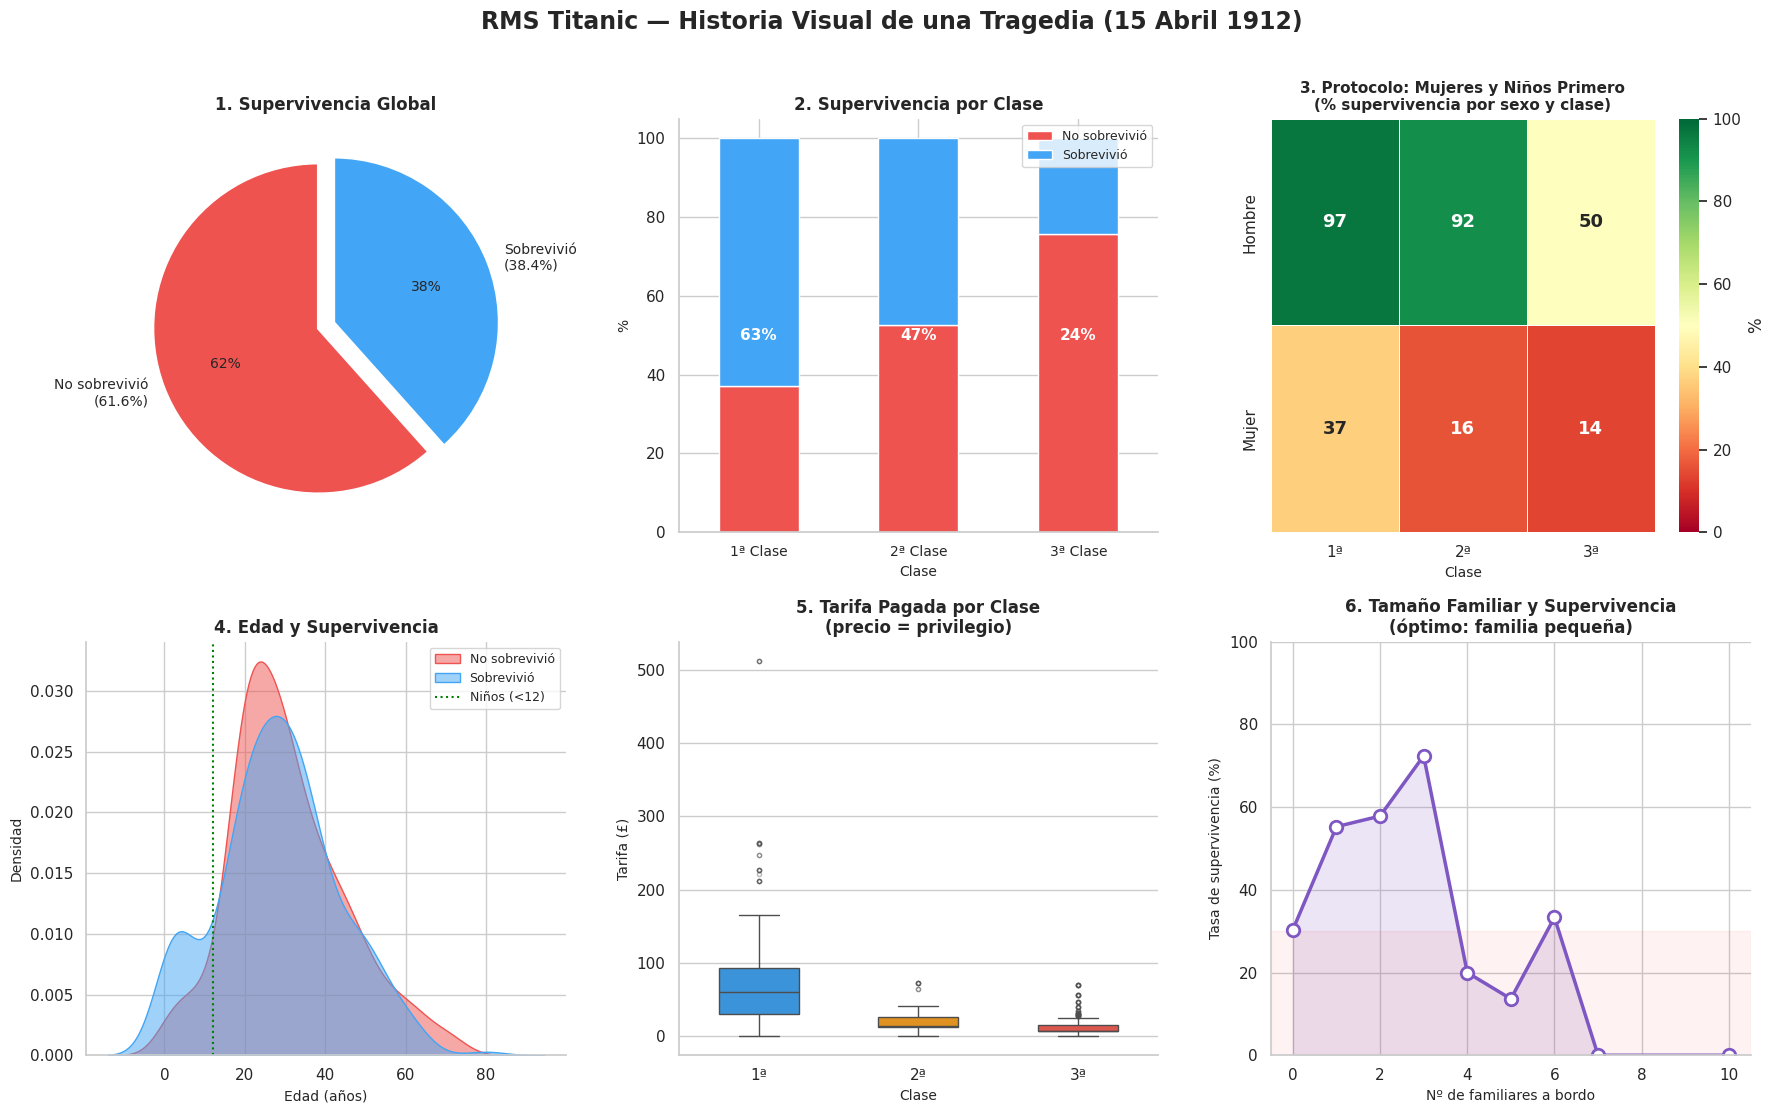

Dashboard guardado como titanic_dashboard.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('RMS Titanic — Historia Visual de una Tragedia (15 Abril 1912)',
             fontsize=17, fontweight='bold', y=1.01)

# ── Subplot 1: Pie de supervivencia global ─────────────────────────────
ax1 = axes[0, 0]
survival_counts = df['Survived'].value_counts()
ax1.pie(survival_counts.values,
        labels=['No sobrevivió\n(61.6%)', 'Sobrevivió\n(38.4%)'],
        colors=['#EF5350', '#42A5F5'],
        autopct='%1.0f%%', startangle=90, explode=(0.05, 0.05),
        textprops={'fontsize': 10}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('1. Supervivencia Global', fontsize=12, fontweight='bold')

# ── Subplot 2: Supervivencia por clase (barras apiladas %) ─────────────
ax2 = axes[0, 1]
sc = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
sc_pct = sc.div(sc.sum(axis=1), axis=0) * 100
sc_pct.index = ['1ª', '2ª', '3ª']
sc_pct.columns = ['No sobrevivió', 'Sobrevivió']
sc_pct.plot(kind='bar', stacked=True, ax=ax2,
            color=['#EF5350', '#42A5F5'], edgecolor='white', width=0.5, legend=False)
for i, cls in enumerate(sc_pct.index):
    v = sc_pct.loc[cls, 'Sobrevivió']
    ax2.text(i, 50, f'{v:.0f}%', ha='center', va='center',
             fontsize=11, fontweight='bold', color='white')
ax2.set_title('2. Supervivencia por Clase', fontsize=12, fontweight='bold')
ax2.set_xlabel('Clase', fontsize=10)
ax2.set_ylabel('%', fontsize=10)
ax2.set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'], rotation=0, fontsize=10)
ax2.legend(['No sobrevivió', 'Sobrevivió'], fontsize=9, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Subplot 3: Heatmap sexo x clase ───────────────────────────────────
ax3 = axes[0, 2]
ssc = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
ssc.index = ['1ª', '2ª', '3ª']
ssc.columns = ['Hombre', 'Mujer']
sns.heatmap(ssc.T, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax3,
            linewidths=0.5, vmin=0, vmax=100,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': '%'})
ax3.set_title('3. Protocolo: Mujeres y Niños Primero\n(% supervivencia por sexo y clase)',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Clase', fontsize=10)
ax3.set_ylabel('', fontsize=10)

# ── Subplot 4: Histograma edades superpuesto ───────────────────────────
ax4 = axes[1, 0]
sns.kdeplot(df[df['Survived']==0]['Age'].dropna(), ax=ax4,
            fill=True, alpha=0.5, color='#EF5350', label='No sobrevivió')
sns.kdeplot(df[df['Survived']==1]['Age'].dropna(), ax=ax4,
            fill=True, alpha=0.5, color='#42A5F5', label='Sobrevivió')
ax4.axvline(12, color='green', linestyle=':', linewidth=1.5, label='Niños (<12)')
ax4.set_title('4. Edad y Supervivencia', fontsize=12, fontweight='bold')
ax4.set_xlabel('Edad (años)', fontsize=10)
ax4.set_ylabel('Densidad', fontsize=10)
ax4.legend(fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Subplot 5: Boxplot tarifas por clase ──────────────────────────────
ax5 = axes[1, 1]
df_bp = df.copy()
df_bp['Clase'] = df_bp['Pclass'].map({1:'1ª', 2:'2ª', 3:'3ª'})
sns.boxplot(data=df_bp, x='Clase', y='Fare', palette=['#2196F3', '#FF9800', '#F44336'],
            order=['1ª', '2ª', '3ª'], width=0.5, ax=ax5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax5.set_title('5. Tarifa Pagada por Clase\n(precio = privilegio)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Clase', fontsize=10)
ax5.set_ylabel('Tarifa (£)', fontsize=10)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Subplot 6: Familia y supervivencia ────────────────────────────────
ax6 = axes[1, 2]
sf = df.groupby('FamilySize')['Survived'].mean() * 100
sc_fam = df.groupby('FamilySize')['Survived'].count()
sf_df = pd.DataFrame({'Rate': sf, 'Count': sc_fam}).reset_index()
ax6.plot(sf_df['FamilySize'], sf_df['Rate'], marker='o', color='#7E57C2',
         linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2)
ax6.fill_between(sf_df['FamilySize'], sf_df['Rate'], alpha=0.15, color='#7E57C2')
ax6.axhspan(0, 30, alpha=0.05, color='red')
ax6.set_title('6. Tamaño Familiar y Supervivencia\n(óptimo: familia pequeña)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Nº de familiares a bordo', fontsize=10)
ax6.set_ylabel('Tasa de supervivencia (%)', fontsize=10)
ax6.set_ylim(0, 100)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('titanic_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado como titanic_dashboard.png')

### Historia del Dashboard

El Titanic no fue una tragedia igual para todos. Solo 4 de cada 10 pasajeros sobrevivieron, y los datos revelan que la suerte no fue aleatoria. El factor más determinante fue la clase social: los pasajeros de Primera Clase tenían el triple de probabilidad de sobrevivir que los de Tercera, porque su posición en el barco les daba acceso directo a los botes salvavidas.

El protocolo de mujeres y niños primero se cumplió, pero solo para las clases altas: las mujeres de Primera y Segunda Clase sobrevivieron casi en su totalidad (97% y 92%), mientras que las mujeres de Tercera Clase solo lo hicieron al 50%. Las tarifas confirman esta brecha: un billete de Primera Clase costaba hasta 100 veces más que uno de Tercera, y ese precio se traducía literalmente en diferencia entre la vida y la muerte.

Finalmente, viajar con una familia pequeña aumentaba las posibilidades de sobrevivir, pero las familias numerosas se convirtieron en una trampa: el vínculo familiar les impidió actuar con la rapidez necesaria.


### Versión Plotly

In [ ]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        '1. Supervivencia Global',
        '2. Supervivencia por Clase',
        '3. Protocolo: Mujeres y Niños',
        '4. Edad y Supervivencia',
        '5. Tarifa Pagada por Clase',
        '6. Tamaño Familiar y Supervivencia'
    ],
    specs=[
        [{'type': 'pie'},       {'type': 'bar'},      {'type': 'heatmap'}],
        [{'type': 'histogram'}, {'type': 'box'},       {'type': 'scatter'}]
    ]
)

# 1. Pie — Supervivencia global
sc_d = df['Survived'].value_counts().sort_index()
fig.add_trace(go.Pie(
    labels=['No sobrevivió', 'Sobrevivió'],
    values=sc_d.values,
    marker_colors=['#EF5350', '#42A5F5'],
    pull=[0.05, 0.05], textinfo='label+percent',
    hovertemplate='<b>%{label}</b><br>%{value} pasajeros (%{percent})<extra></extra>',
    showlegend=False
), row=1, col=1)

# 2. Barras apiladas — por clase
sc2_d     = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
sc2_d.index = ['1ª', '2ª', '3ª']
sc2_d.columns = ['No sobrevivió', 'Sobrevivió']
sc2_pct   = sc2_d.div(sc2_d.sum(axis=1), axis=0) * 100
for col, color in zip(['No sobrevivió', 'Sobrevivió'], ['#EF5350', '#42A5F5']):
    fig.add_trace(go.Bar(
        name=col, x=sc2_pct.index, y=sc2_pct[col].round(1),
        marker_color=color, showlegend=False,
        hovertemplate=f'<b>%{{x}} Clase</b><br>{col}: %{{y:.1f}}%<extra></extra>'
    ), row=1, col=2)

# 3. Heatmap — sexo × clase
ssc_d = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
ssc_d.index   = ['1ª', '2ª', '3ª']
ssc_d.columns = ['Hombre', 'Mujer']
fig.add_trace(go.Heatmap(
    z=ssc_d.T.values,
    x=ssc_d.index.tolist(),
    y=['Hombre', 'Mujer'],
    colorscale='RdYlGn', zmin=0, zmax=100,
    text=ssc_d.T.round(0).values,
    texttemplate='%{text:.0f}%', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b> · <b>%{x} Clase</b><br>Supervivencia: %{z:.1f}%<extra></extra>',
    showscale=False
), row=1, col=3)

# 4. Histograma superpuesto — edades
for grp, color, name in [(1, '#42A5F5', 'Sobrevivió'), (0, '#EF5350', 'No sobrevivió')]:
    fig.add_trace(go.Histogram(
        x=df[df['Survived'] == grp]['Age'].dropna(),
        nbinsx=20, marker_color=color, opacity=0.55, name=name,
        hovertemplate='Edad: %{x:.0f} años<br>Pasajeros: %{y}<extra></extra>',
        showlegend=False
    ), row=2, col=1)

# 5. Boxplot — tarifas
for pclass, nombre, color in [(1, '1ª', '#2196F3'), (2, '2ª', '#FF9800'), (3, '3ª', '#F44336')]:
    fig.add_trace(go.Box(
        y=df[df['Pclass'] == pclass]['Fare'],
        name=nombre, marker_color=color, showlegend=False,
        hovertemplate=f'<b>{nombre} Clase</b><br>Tarifa: £%{{y:.2f}}<extra></extra>'
    ), row=2, col=2)

# 6. Línea — familia y supervivencia
sf_d = df.groupby('FamilySize')['Survived'].mean() * 100
cnt_d = df.groupby('FamilySize').size()
fig.add_trace(go.Scatter(
    x=sf_d.index, y=sf_d.values.round(1),
    mode='lines+markers',
    marker=dict(size=8, color='#7E57C2', line=dict(color='white', width=1.5)),
    line=dict(color='#7E57C2', width=2),
    fill='tozeroy', fillcolor='rgba(126,87,194,0.12)',
    customdata=cnt_d.values,
    hovertemplate='<b>%{x} familiar(es)</b><br>Supervivencia: %{y:.1f}%<br>n=%{customdata}<extra></extra>',
    showlegend=False
), row=2, col=3)

fig.update_layout(
    title=dict(
        text='RMS Titanic — Dashboard Interactivo de una Tragedia (15 Abril 1912)',
        font=dict(size=15)
    ),
    barmode='stack',
    plot_bgcolor='white',
    height=760,
    hoverlabel=dict(bgcolor='white', font_size=11)
)
fig.update_yaxes(gridcolor='lightgrey')
fig.show()


---
## Reflexión Final

**¿Qué gráfico te resultó más difícil de elegir?**  
La Pregunta 13 (familia y supervivencia) fue la más difícil porque la relación no es lineal: ni un boxplot simple ni una barra agrupada capturaban bien la forma de "U invertida" que existe. El gráfico de líneas con puntos fue la mejor opción porque revelaba el óptimo en familias de 1-3 miembros y la caída en familias grandes.

**¿Hubo alguna pregunta donde varios tipos de gráfico eran igualmente válidos?**  
Sí, la Pregunta 7 (tasa de supervivencia global). Un gráfico de barras era igualmente válido que el pie chart. Elegí el pie chart porque la pregunta pedía explícitamente ver el "peso relativo" de cada grupo dentro del total, y para dos categorías y proporción de un todo, el pie chart comunica eso de forma más inmediata e intuitiva.

**¿Qué hallazgo te sorprendió más?**  
El más sorprendente fue que las mujeres de la Tercera Clase solo sobrevivieron al 50%, similar a los hombres de 1ª Clase. El protocolo de mujeres primero fue selectivo: funcionó para las mujeres ricas, pero no garantizó la vida a las mujeres pobres. Ser mujer en el Titanic no era suficiente, había que ser también de clase alta.